In [1]:
# 06 -- like 05, but I'm adding in the per-interpreter variability


In [23]:
# Example stack config as a pure Python dict

landscape_stack_config = {
    "id_prefix": "DL",
    "id_strategy": "hash",   # or "uuid"
    "explicit_id": None,     # set to a string if you want to force an ID

    # --- Base disturbance landscape setup ---
    "tif_path": "downloaded_images/snic_10_2019_-12.004_132.979.tif",  # <-- change to your SNIC patch raster

    "disturbance_config": {
        "random": {
            "seed": None,    # or an int for reproducibility
        },
        "raster": {
            "band": 1,
        },
        "types": {
            "type1": {
                "name": "Conifer",
                "proportion_of_patches": 0.6,
                "initial_cover": {
                    "target_mean": 0.90,   # in (0,1)
                    "kappa": 20.0,
                },
                "proportional_loss": {
                    "mixture": {
                        "catastrophic_probability": 0.02,
                        "background_alpha": 0.3,
                        "background_beta": 8.0,
                        "catastrophic_alpha": 8.0,
                        "catastrophic_beta": 0.7,
                    }
                },
            },
            "type2": {
                "name": "Broadleaf",
                "proportion_of_patches": 0.4,
                "initial_cover": {
                    "target_mean": 0.85,
                    "kappa": 18.0,
                },
                "proportional_loss": {
                    "mixture": {
                        "catastrophic_probability": 0.05,
                        "background_alpha": 0.4,
                        "background_beta": 7.0,
                        "catastrophic_alpha": 7.0,
                        "catastrophic_beta": 0.8,
                    }
                },
            },
        },
        "thresholds": {
            "final_cover_percent": 15.0,
        },
        "simulation": {
            "max_retries": 10,
        },
        # Optional plotting defaults (you can ignore or tweak later)
        "plotting": {
            "type_cmap": "tab10",
            "initial_cover_cmap": "Greens",
            "proportional_loss_cmap": "Oranges",
            "loss_abs_cmap": "Reds",
            "final_cover_cmap": "Blues",
            "disturbed_cmap": "Greys_r",
        },
    },

    # --- Sensor configurations (arbitrary number of sensors) ---
    "sensors": [
        {
            "name": "Landsat_OLI",
            "config": {
                "signal_transform": {
                    "max_signal": 1000.0,
                    "curve_k": 3.0,
                },
                "gaussian_patch_noise": {
                    "std_proportion_of_range": 0.0,
                },
                "types": {
                    # override type-specific behavior if desired
                    "type1": {
                        "gaussian_patch_noise": {
                            "std_proportion_of_range": 0.0,
                        }
                    },
                    "type2": {
                        "gaussian_patch_noise": {
                            "std_proportion_of_range": 0.0,
                        }
                    },
                },
                "lowpass_filter": {
                    "kernel_size": 0,
                },
                "spatial_noise": {
                    "spatial_autocorr_distance": 10.0,
                    "amplitude_proportion_of_range": 0.0,
                },
            },
        },

        {
            "name": "Sentinel2_MSI",
            "config": {
                "signal_transform": {
                    "max_signal": 1500.0,
                    "curve_k": 2.5,
                },
                "gaussian_patch_noise": {
                    "std_proportion_of_range": 0.015,
                },
                "lowpass_filter": {
                    "kernel_size": 5,
                },
                "spatial_noise": {
                    "spatial_autocorr_distance": 15.0,
                    "amplitude_proportion_of_range": 0.12,
                },
            },
        },
    ],

    # --- Interpreter configuration (single interpreter) ---
    "interpreter": {
        "name": "DefaultInterpreter",
        "config": {
            "detection_curve": {
                "pivot_loss": 15.0,
                "slope": 0.3,
            },
            "definition_curve": {
                "slope": 0.4,
                "threshold_override": None,  # use DisturbanceLandscape threshold by default
            },
            "gaussian_patch_noise": {
                "std_dev_percent": 1.0,
            },
            "beta_patch_uncertainty": {
                "alpha": 0.1,
                "beta": 12.0,
            },
            "lowpass_filter": {
                "kernel_size": 0,
            },
            "spatial_uncertainty": {
                "spatial_autocorr_distance": 8.0,
                "max_scaler": 0.0001,
            },
        },
    },
}

In [24]:
train_experiment_config = {
    "n_stacks": 2,
    "disturbance_seed_base": 10_000,
    "use_separate_seeds_per_stack": True,

    "patch_dir": "downloaded_images/",
    "patch_selection_seed": 123,

    "sensor_name_for_strat": "Landsat_OLI",
    "n_strata": 5,
    "samples_per_stratum": 50,
    "kappa_for_logistic":2.0, # 1.0 is strict logistic, higher is steeper. 
    "sampling_seed": 42,
}

In [25]:
# set up the interpreters

# new to 06 -- the interpreter stuff
from interpreter_agent import InterpreterAgent, InterpreterGroup

model_building_interp_cfg = {
    "interpreter_id": "interpreterBuildingModel",
    "consistency_std_pct": 0.00,
    "bias_std_pct": 0.0,
    "confidence_std": 0.0,
    "seed": 101,
}
model_interp1 = InterpreterAgent(**model_building_interp_cfg)

validation_interp1_cfg = {
    "interpreter_id": "validation_interp1",
    "consistency_std_pct": 0.0,
    "bias_std_pct": 0.0,
    "confidence_std": 0.0,
    "seed": 101,
}
val_interp1 = InterpreterAgent(**validation_interp1_cfg)


# usage later:  
# train_collection.buildModel(
#     sensor_names=None,
#     n_strata=5,
#     samples_per_stratum=200,
#     sampling_seed=123,
#     interpreter_agent=expert_1,
# )

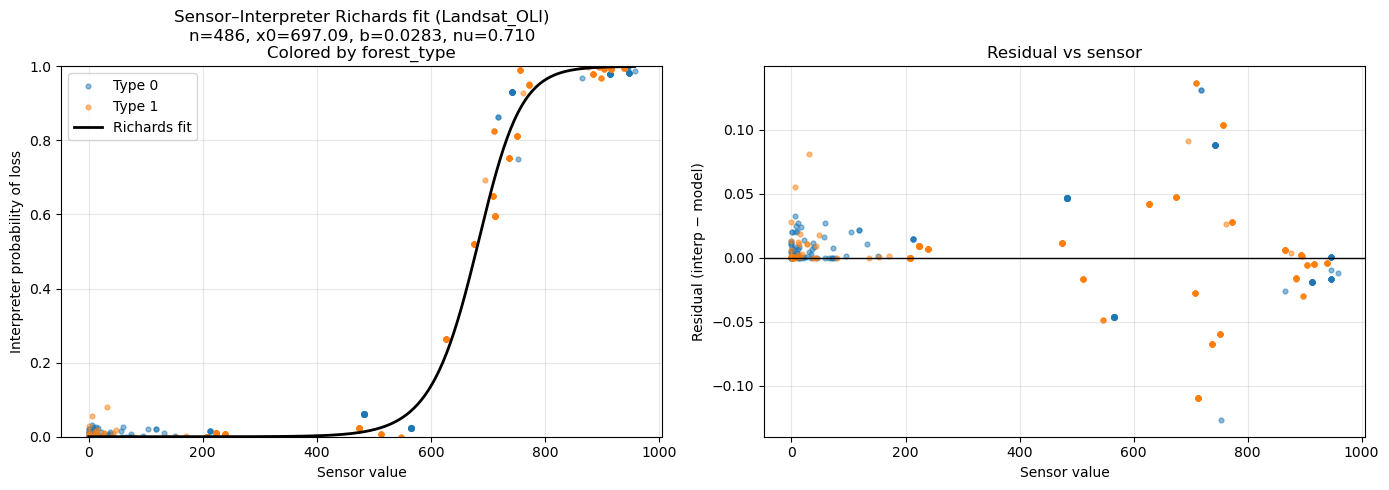

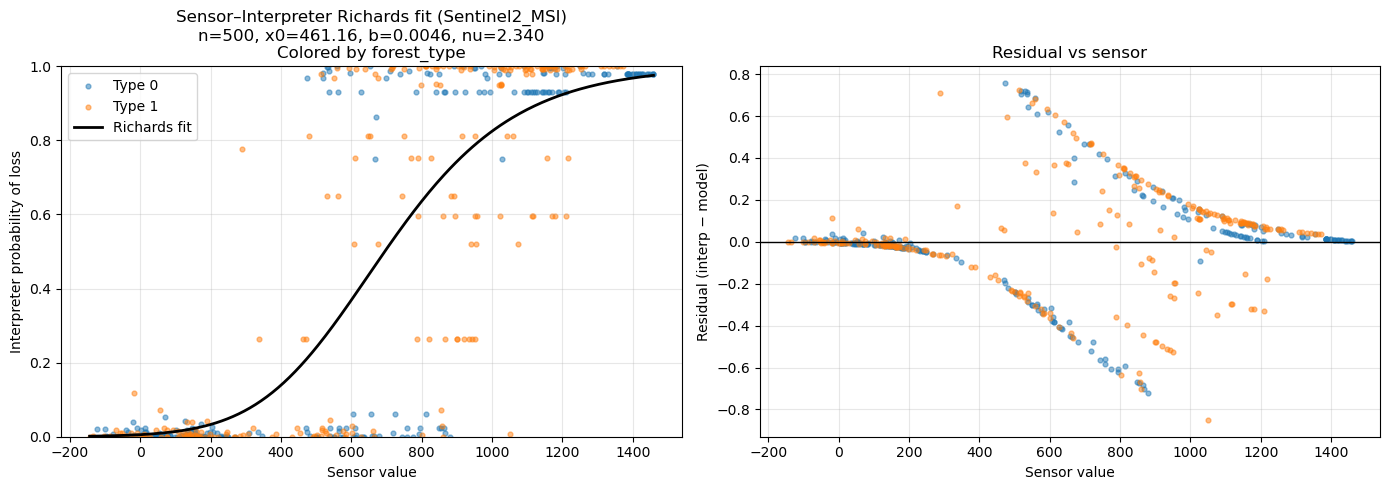

'experiment_logs/run_ID_20251214_141358_20b1dc.csv'

In [41]:
import landscape_stack_collection 
import importlib 
importlib.reload(landscape_stack_collection)
from landscape_stack_collection import LandscapeStackCollection

from disturbance_helper_functions import flatten_config, generate_run_id, _append_to_master_log, export_with_metadata


train_collection = LandscapeStackCollection.from_config(
    stack_template_cfg=landscape_stack_config,
    experiment_cfg=train_experiment_config,
)

#adding in the interpreter agent

trained_models = train_collection.buildModel(
                    sensor_names=None,
                    n_strata=5,
                    samples_per_stratum=50,
                    sampling_seed=123,
                    interpreter_agent=model_interp1,
                            )   #continuous logistic probability

experiment_config = {
    "landscape_stack_config":  landscape_stack_config, 
    "experiment_config": train_experiment_config,
    "training_interp_config": model_building_interp_cfg
}

export_with_metadata(experiment_config, notes="Basic defaults")




In [42]:
# next build a validation dataset from a different set of landscapes
#  to do this, we need to make sure that the landscapes are different.  

used_tifs = [s.base_landscape.tif_path for s in train_collection.stacks]

val_experiment_config = {
    "n_stacks": 1,   # or however many you want for this second set
 #   "disturbance_seed_base": 20_000,
  #  "use_separate_seeds_per_stack": True,

    "patch_dir": "downloaded_images/",
   # "patch_selection_seed": 456,  # different seed from training if you want

    "sensor_name_for_strat": "Landsat_OLI",
    "n_strata": 5,
    "samples_per_stratum": 200,
#    "sampling_seed": 99,
}

val_collection = LandscapeStackCollection.from_config(
    stack_template_cfg=landscape_stack_config,
    experiment_cfg=val_experiment_config,
    exclude_tif_paths=used_tifs,
)



Fitted interpreter-probability model for sensor 'Landsat_OLI': x0=0.464, k=7.631


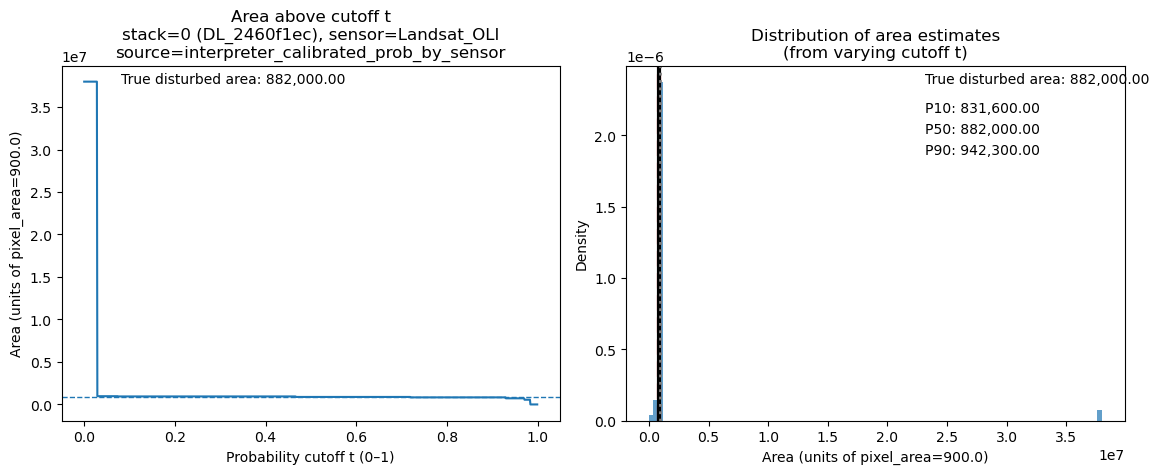

10th, 50th, and 90th percentile areas: 831,600.00, 882,000.00, 942,300.00
True area: 882,000.00


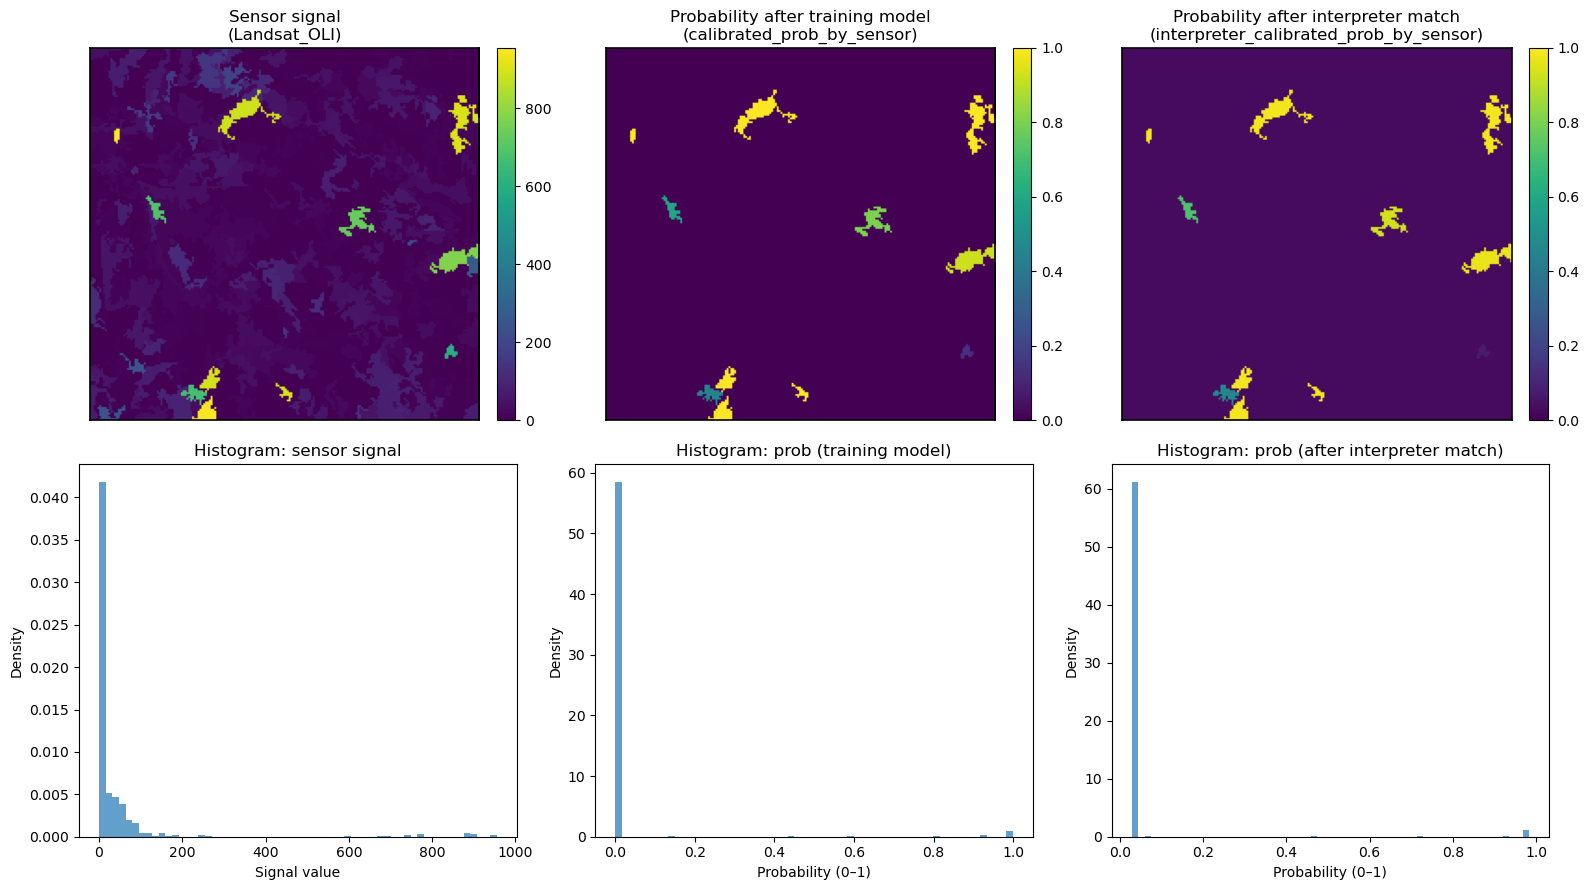

In [43]:
# apply the logistic to the validation collection

# load the model from the training collection (a couple panels up ^ )

val_collection.loadModel(trained_models)

val_collection.applyModel()

val_collection.buildInterpreterProbModel(
        sensor_name= "Landsat_OLI", 
        n_strata= 5,
        samples_per_stratum=100,
        sampling_seed=11, 
        interpreter_agent=val_interp1
    )

val_collection.applyInterpreterProbModel(
        sensor_name="Landsat_OLI", 
        store_attr_name="interpreter_calibrated_prob_by_sensor"
    )

val_collection.plot_area_distribution_for_stack(
    stack_index=0,
    sensor_name="Landsat_OLI",
    prob_source_attr="interpreter_calibrated_prob_by_sensor",
    pixel_area=900.0,
    step=0.001,
    bins=100,
    show_true_area=True,
    show_diagnostics=True,
)

